In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *
# %matplotlib widget

L1 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD5n1")[0]
L2 = read_parameters("/data1/DATA_Duplat/Brut/PDF/PD5n1")[1]

lengthtab = L1 * L2
nbins = 100
Tnmin = np.array([5,8, 8,8,7,7,7, 8,8,8,8, 8, 8, 8,8])
Tnmax = np.array([80,45,50,50,50,50,50, 80,80,80,80,80,80,80])
fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD5n{nb}' for nb in fnb]
""" folderpath = np.insert(folderpath, 8, '/data1/DATA_Duplat/Brut/PDF/PD8n1') """
Tvar = [read_parameters(folder)[2] for folder in folderpath]

In [26]:
Tndist_s, Tndatafit_s, Tnstat_s, Tnonzero_s, Tmean_s, Tnbins_s = np.array(Parallel(n_jobs=-1)(delayed(process_size_from_histo)(folder, lengthtab, nmin, nmax)
                                                                    for (folder, nmin, nmax) in zip(folderpath, Tnmin, Tnmax))).T

<ipython-input-26-51439b92fb5d>:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  Tndist_s, Tndatafit_s, Tnstat_s, Tnonzero_s, Tmean_s, Tnbins_s = np.array(Parallel(n_jobs=-1)(delayed(process_size_from_histo)(folder, lengthtab, nmin, nmax)


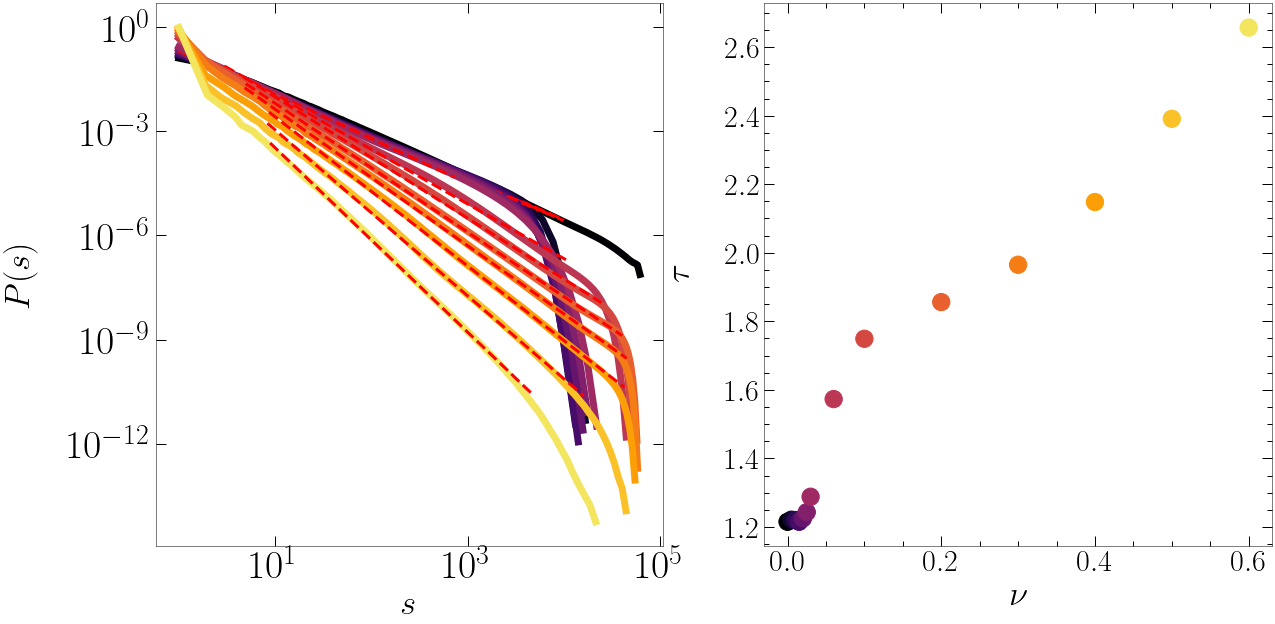

In [27]:
Tstop_x = [4.e3, 1e-8, 7e-10,  1.1e-8, 1e-6,5e-5,5e-5,1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-11, 1e-11]
Tstart_x = [0,4,4,1,1,0,1,2,4,4,4,8,8,8,8]
""" Tstop_x = [1e-8]
Tstart_x = [0] """

NCURVES = len(Tvar)

colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

Thisto_s, Txfit_s, Tyfit_s, Ttau_s, Tperr_s = PDF_s_histogram(Tndist_s, Tstart_x, Tstop_x, Tvar)

chi2 = np.zeros(len(Tvar))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20,10))
for i, (histo, xfit, yfit, tau, nu) in enumerate(zip(Thisto_s, Txfit_s, Tyfit_s, Ttau_s, Tvar)):
    ax1.plot(histo[:,0],histo[:,1], color = colors[i],linewidth=7, label = f"{nu}\nb = {-Tnstat_s[i]:.2f}")
    ax1.plot(xfit, yfit, 'r--', lw = 3)
    
ax2.scatter(Tvar, -Ttau_s, color = colors[:], zorder=2, marker = 'o', s = 300, label = r'$\tau$')

para_fig(ax1, r'$s$', r'$P(s)$', type = 'loglog', labelsize = 35, tickssize= 40, width_M = 1, length_M = 10)
para_fig(ax2, r'$\nu$', r'$\tau$', type = 'lin', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)


plt.show()

Somme des proba new script: 1.0
Somme des proba new script: 1.0000000000000002
Somme des proba new script2:  0.6337031572996759
(35, 2)


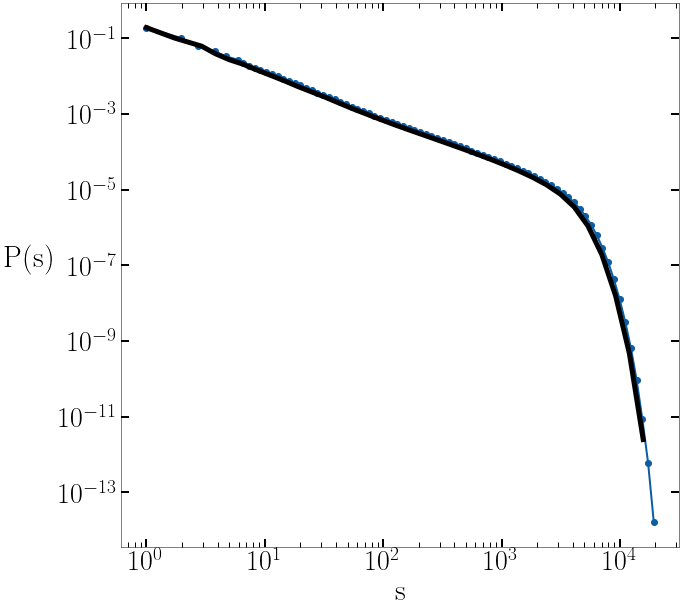

In [29]:
L1 = 256
L2 = 256

lengthtab = L1 * L2
nbins = 100

data = np.loadtxt(f"/data1/DATA_Duplat/Brut/PDF/PD5n5/stat_histosize.txt", comments = "#") #load linear histogram

log_bins = np.logspace(np.log10(1), np.log10(len(data)), nbins + 1)
log_histo = np.zeros(nbins)
lin_bins = np.arange(0, len(data))
# print(linbins)

norm_data = data/np.sum(data)
for i in range(len(log_bins) - 1): #Take the lin histo and turn it into a log histo
    # Trouver les bins linéaires qui chevauchent le bin logarithmique courant
    overlap = (lin_bins >= log_bins[i]) & (lin_bins < log_bins[i + 1])
    # Ajouter les comptages de ces bins linéaires au bin logarithmique
    if len(norm_data[overlap])!=0:
        log_histo[i] = np.sum(norm_data[overlap])/len(norm_data[overlap])
        # log_histo[i] = np.sum(data[overlap])
        
# Renorm the histogram
bin_widths = np.diff(log_bins)  # Largeur de chaque bin logarithmique
area = np.sum(log_histo * bin_widths)  # Calcul de l'aire sous la courbe
log_histo_normalized = log_histo / area  # Normalisation


mask2 = log_histo_normalized != 0

print("Somme des proba new script:", np.sum(log_histo_normalized * bin_widths ))
print("Somme des proba new script:", np.sum(log_histo_normalized[mask2] * bin_widths[mask2] ))
print("Somme des proba new script2: ", np.sum(log_histo))

histo = Thisto_s[4]

print(np.shape(histo))



plt.figure(figsize = (10,10))
plt.plot(log_bins[:-1][mask2], log_histo[mask2], lw=2, marker = 'o')

plt.plot(histo[:,0], histo[:,1], color = 'k',linewidth=5)

plt.xscale("log")
plt.yscale("log")
plt.xlabel('s', fontsize=30)
plt.ylabel('P(s) ', fontsize=30, rotation = 0, labelpad = 30)
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()

In [2]:
Thisto_s2, Tbins_s2, Tnonzero_s2, Tmean_s2,Tnbins_s2 = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))
                                                                    for  folder in folderpath)).T



<ipython-input-2-3f4b145b6271>:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  Thisto_s2, Tbins_s2, Tnonzero_s2, Tmean_s2,Tnbins_s2 = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histosize.txt".format(folder))


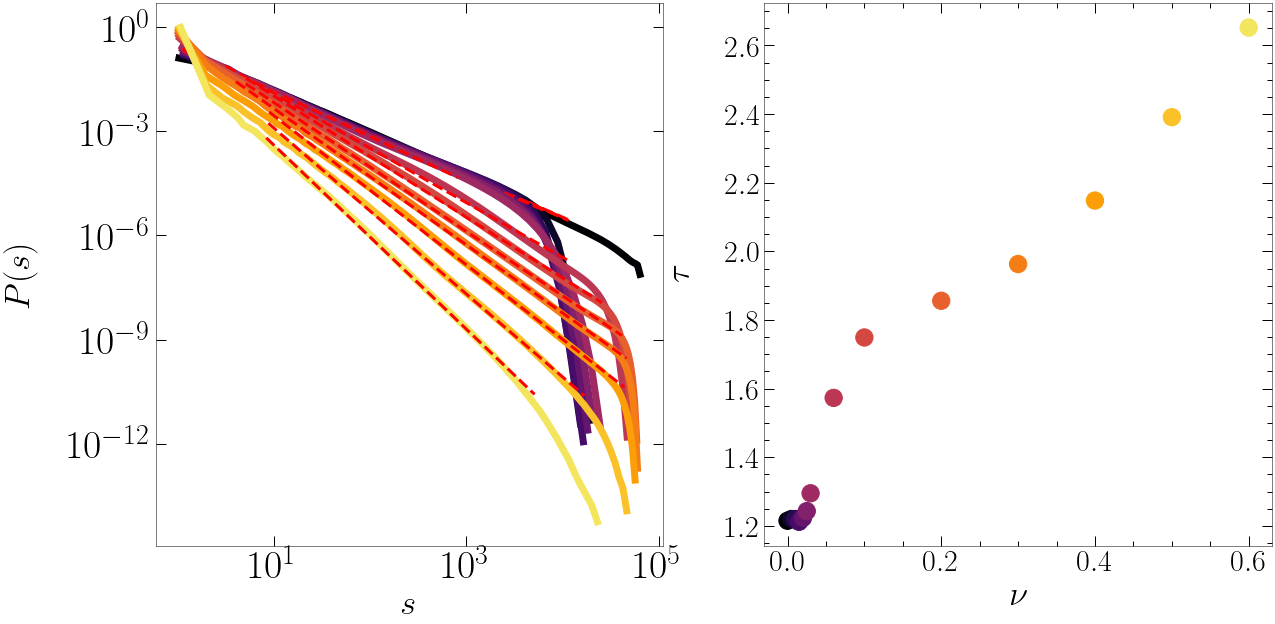

In [ ]:
Tstop_x = [4.e3, 1e-8, 7e-10,  1.1e-8, 1e-6,5e-5,5e-5,1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-11, 1e-11]
Tstart_x = [0,4,4,1,1,0,1,2,4,4,4,8,8,8,8]

Txfit, Tyfit, Ttau_s2, Tperr = PDF_fitting(Thisto_s2, Tbins_s2, Tstart_x, Tstop_x, Tvar)

NCURVES = len(Tvar)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]
chi2 = np.zeros(len(Tvar))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20,10))
for i, (histo, bins, xfit, yfit) in enumerate(zip(Thisto_s2, Tbins_s2, Txfit, Tyfit,)):
    
    ax1.plot(bins,histo, color = colors[i],linewidth=7)
    ax1.plot(xfit, yfit, 'r--', lw = 3)
    
ax2.scatter(Tvar, -Ttau_s2, color = colors[:], zorder=2, marker = 'o', s = 300, label = r'$\tau$')

para_fig(ax1, r'$s$', r'$P(s)$', type = 'loglog', labelsize = 35, tickssize= 40, width_M = 1, length_M = 10)
para_fig(ax2, r'$\nu$', r'$\tau$', type = 'lin', labelsize = 35, tickssize= 30, width_M = 1, length_M = 10)


plt.show()

In [ ]:
lengthtab = L1 * L2 * 1000
results_t = Parallel(n_jobs=-1)(delayed(process_top)(folder, lengthtab, nbins, nmin, nmax)
                                  for (folder, nmin, nmax) in zip(folderpath, Tnmin, Tnmax))

Tndist_t, Tndatafit_t, Tnstat_t, Tnzero_t, Tmean_t = np.array(results_t).T

<ipython-input-3-afcc2e8db37b>:5: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  Tndist_t, Tndatafit_t, Tnstat_t, Tnzero_t, Tmean_t = np.array(results_t).T


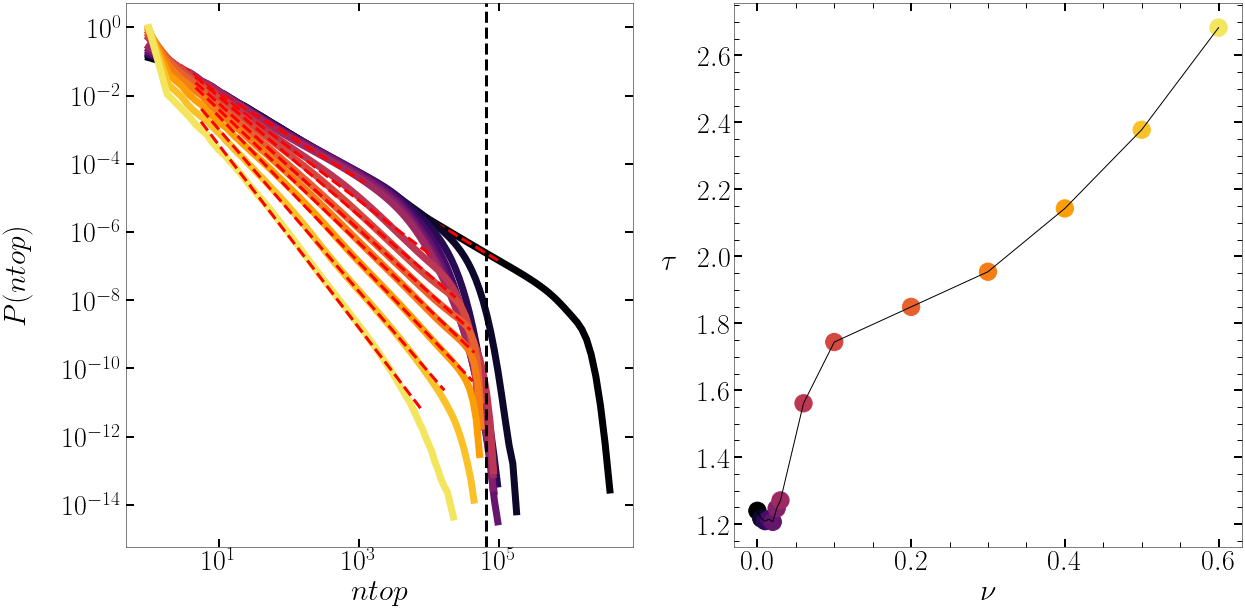

In [4]:
Tstop = [1e5, 3e-4, 4e-4, 8.5e-5, 4e-5,
        5e-5, 3e-5, 1e-7, 1e-8, 1e-9,
        1e-10, 1e-11, 1e-11, 1e-12]
Tstart_x = [0,1,1,1,1,2,1,2,4,4,4,8,5,5]

NCURVES = len(Tvar)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]

Thisto, Txfit, Tyfit, Ttau_t, Tperr_t = PDF_top_histogram(Tndist_t, Tstart_x, Tstop, Tvar)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20,10))
for histo, xfit, yfit, tau_t, color in zip(Thisto, Txfit, Tyfit, Ttau_t, colors):
    ax1.plot(histo[:, 0], histo[:,1], color = color, lw = 7)
    ax1.plot(xfit, yfit, 'r--', lw = 3)


ax2.scatter(Tvar, -Ttau_t, color = colors[:], marker = 'o', s = 300)
ax2.plot(Tvar, -Ttau_t, linestyle = '-', c = 'k', zorder=1)

ax1.axvline(L1 * L2, c = 'k', lw = 3, ls ='--')
para_fig(ax1, r"$ntop$", r"$P(ntop)$", type = 'loglog')

# ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
""" plt.legend(title_fontsize = 23, ncol = 2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25) """
plt.show()

In [9]:
Thisto_t2, Tbins_t2, Tnonzero_t2, Tmean_t2,Tnbins_t2 = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histotop.txt".format(folder))
                                                                    for  folder in folderpath)).T

<ipython-input-9-f72432cf1d8e>:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  Thisto_t2, Tbins_t2, Tnonzero_t2, Tmean_t2,Tnbins_t2 = np.array(Parallel(n_jobs=-1)(delayed(new_PDF)("{}/stat_histotop.txt".format(folder))


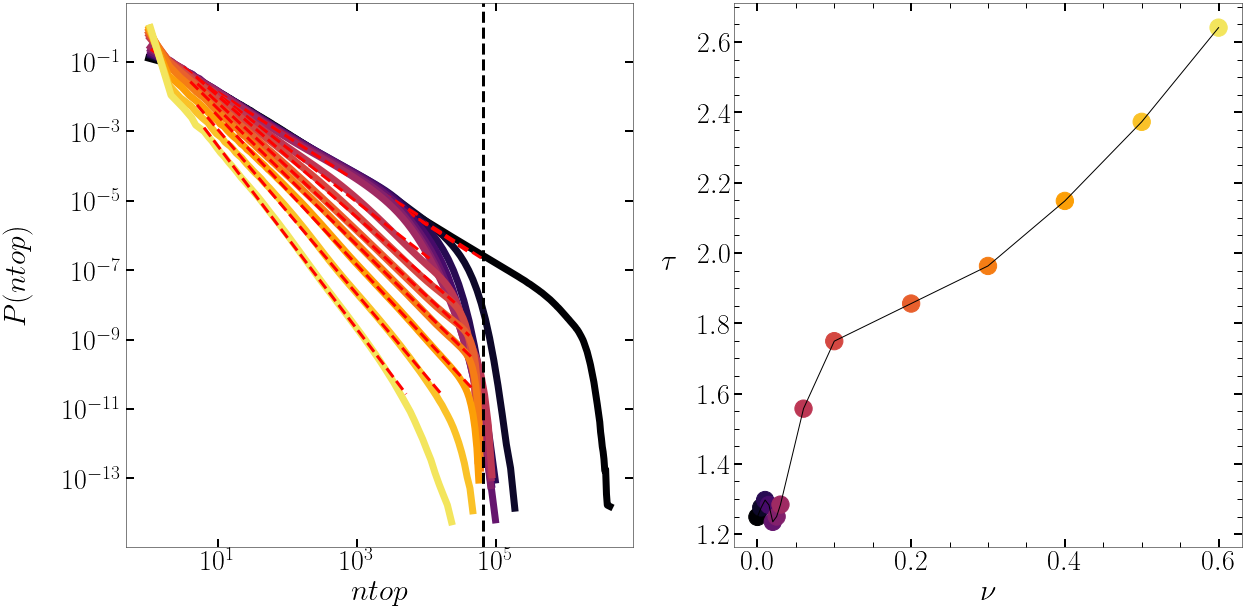

In [11]:
Tstop = [1e5, 3e-4, 4e-4, 8.5e-5, 4e-5,
        5e-5, 3e-5, 1e-7, 1e-8, 1e-9,
        1e-10, 1e-11, 1e-11, 1e-12]
Tstart_x = [0,1,1,1,1,2,1,2,4,4,4,8,5,5]

NCURVES = len(Tvar)
colors = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]
Txfit_t2, Tyfit_t2, Ttau_t2, Tperr = PDF_fitting(Thisto_t2, Tbins_t2, Tstart_x, Tstop_x, Tvar)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (20,10))
for histo, bins, xfit, yfit, tau_t, color in zip(Thisto_t2,Tbins_t2, Txfit_t2, Tyfit_t2, Ttau_t2, colors):
    ax1.plot(bins, histo, color = color, lw = 7)
    ax1.plot(xfit, yfit, 'r--', lw = 3)


ax2.scatter(Tvar, -Ttau_t2, color = colors[:], marker = 'o', s = 300)
ax2.plot(Tvar, -Ttau_t2, linestyle = '-', c = 'k', zorder=1)

ax1.axvline(L1 * L2, c = 'k', lw = 3, ls ='--')
para_fig(ax1, r"$ntop$", r"$P(ntop)$", type = 'loglog')

# ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
""" plt.legend(title_fontsize = 23, ncol = 2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25) """
plt.show()